# Understanding evolution in the $P-\dot{P}$

In this notebook, we show how the different ingredients in the magneto-rotational evolution play a role in determining the evolutionary tracks in the $P-\dot{P}$ diagram.
In particular, we show the evolutionary tracks for two model pulsars where the initial properties ($P_0$, $B_0$ and $\chi_0$) can be changed at will. We can see how the magnetic-field decay and the alignment (decrease in $\chi$) shape the trajectories for different values of the initial properties.

Here we summarize the outcome for several meaningful example cases.
Choosing different magnetic fields for the two stars causes the stars to evolve on very different tracks and is, therefore, the most relevant and evident effect. In the following, we will keep the same magnetic-field value for both stars and instead focus on more subtle effects like the alignment and the choice of initial spin period and inclination angle.

## Without alignment

Let's fix the inclination angle to $\pi/2$ (implying that $\dot{\chi} = 0$) for both stars and consider how choosing different initial spin periods affects the results depending on the initial magnetic field. For example, consider the following spin periods: 

`P_initial = np.array([0.01, 0.1])`

and try different field values $10^{12}$, $10^{13}$, $10^{14}$ G (the same for both stars).

For the lowest field value, the track stay separated as the spin-down is not very effective and eventually the field decays. 
Therefore, the initial spin period is still imprinted onto the final outcome (green points below).
For the higher two fields, the pulsars end up evolving on the same evolutionary track and attain the same final spin period. The evolution loses complete memory of the initial spin period.

If we consider two extreme values of the inclination angle (again both stay constant):

`chi_initial = np.array([0 * np.pi / 2, np.pi / 2])`

This time, the pulsars will evolve on slightly separated tracks and end up with different final periods for all fields. 
However, especially for higher fields, these final periods will not depend on the initial spin-period values. 
Again, the evolution loses memory of the initial spin periods for higher fields.

## With alignment

If the two pulsars start with the same inclination angle but different initial periods, for low magnetic fields the two evolutionary tracks are separated again because the spin-down is not very effective and the magnetic field decays. For higher magnetic fields, the two stars again end up evolving on the same track and with the same final period. 

If the two pulsars start with very different inclination angles (one almost aligned and one almost orthogonal) and different initial periods, the evolution tracks can stay separated even for higher magnetic-field values. 
For example, with see this last case for the following initial conditions:

`B_initial = np.array([1e14, 1e14])`

`chi_initial = np.array([0.1 * np.pi / 2, 0.9 * np.pi / 2])`

`P_initial = np.array([0.01, 0.1])`

This is due to the fact that the second star that is almost orthogonal and starts with a higher spin period does not reach an aligned state at all, i.e., the misalignment angle does not decrease to 0.

However, this is very case-dependent because by inverting the spin period values for the two stars the two evolutionary tracks becomes asymptotically similar again, losing memory of their birth periods.


## Overall comments

In general, the smaller the initial spin period the easier it is to lose memory during the evolution.
Pulsars that are born with already high values of the spin period will more likely follow separated evolutionary tracks even for higher magnetic fields so that it is easier to differentiate between pulsars born with different spin periods. Note however that this is only the case if the magnetic field decays. If the field stays constant these cases are also degenerate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl
from scipy.integrate import quad
from scipy.optimize import curve_fit
from pypopsyn.simulator.config_simulator import cfg
import pypopsyn.simulator.basics.constants as const
import pypopsyn.simulator.multiband_emission.emission_radio as er
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

import utilities.plot_settings

import pypopsyn.simulator.magneto_rotational_physics.magneto_rotational_evolution_fit as mre
import pypopsyn.simulator.magneto_rotational_physics.period_derivative as pdv

from scipy.integrate import odeint

In [2]:
cfg["t_age_max"] = 1e8

# Set the right parameters for the analytical fit of the magnetic-field evolution depending on the
# magneto-thermal model.
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    a1 = cfg["a1_SLy4_dip-tor"]
    a2 = cfg["a2_SLy4_dip-tor"]
    A1 = cfg["A1_SLy4_dip-tor"]
    A2 = cfg["A2_SLy4_dip-tor"]
    b1 = cfg["b1_SLy4_dip-tor"]
    b2 = cfg["b2_SLy4_dip-tor"]
    tau_late = cfg["tau_late_SLy4_dip-tor"]
elif (cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy") or (
        cfg["magneto-thermal_model"] == "BKS24_dip-tor_light"
):
    a1 = cfg["a1_BKS24_dip-tor"]
    a2 = cfg["a2_BKS24_dip-tor"]
    A1 = cfg["A1_BKS24_dip-tor"]
    A2 = cfg["A2_BKS24_dip-tor"]
    b1 = cfg["b1_BKS24_dip-tor"]
    b2 = cfg["b2_BKS24_dip-tor"]
    tau_late = cfg["tau_late_BKS24_dip-tor"]

# Set the initial conditions.
log_B0 = np.array([12, 13, 14, 15])
B_initial = 10**log_B0
chi_initial = np.array([0.8 * np.pi / 2, 0.8 * np.pi / 2, 0.8 * np.pi / 2, 0.8 * np.pi / 2])
P_initial = np.array([0.001, 0.001, 0.001, 0.001])
t_age = np.array([cfg["t_age_max"], cfg["t_age_max"], cfg["t_age_max"], cfg["t_age_max"]])
a_late = cfg["a_late"]
cfg["save_magrot_evolution"] = True

# Create a colormap and normalize it.
cmap = plt.cm.viridis
norm = Normalize(vmin=min(log_B0), vmax=max(log_B0))

In [3]:
P_dot_initial = np.zeros(len(log_B0))

for i in range(len(P_dot_initial)):
    P_dot_initial[i] = (
        pdv.period_derivative(
            B_initial[i], chi_initial[i], P_initial[i]
        )
        / const.YR_TO_S
    )

In [4]:
t = [np.array([]) for _ in range(len(log_B0))]
B = [np.array([]) for _ in range(len(log_B0))]
chi = [np.array([]) for _ in range(len(log_B0))]
P = [np.array([]) for _ in range(len(log_B0))]
P_dot = [np.array([]) for _ in range(len(log_B0))]

In [5]:
B_final, chi_final, P_final, evolution_dictionary = mre.magneto_rotational_evolution(B_initial, chi_initial, P_initial, t_age, a1, a2, A1, A2, b1, b2, tau_late, a_late)

for i in range(len(log_B0)):
    t[i] = evolution_dictionary[i]["t"]
    B[i] = evolution_dictionary[i]["B(t)"]
    chi[i] = evolution_dictionary[i]["chi(t)"]
    P[i] = evolution_dictionary[i]["P(t)"]

In [6]:
period_derivative_vect = np.vectorize(pdv.period_derivative)

for i in range(len(log_B0)):
    P_dot[i] = period_derivative_vect(B[i], chi[i], P[i]) / const.YR_TO_S

In [7]:
P_final_test = np.array([P[i][-1] for i in range(len(log_B0))])
P_dot_final = np.array([P_dot[i][-1] for i in range(len(log_B0))])

Check the evolution in the $P-\dot{P}$ diagram.

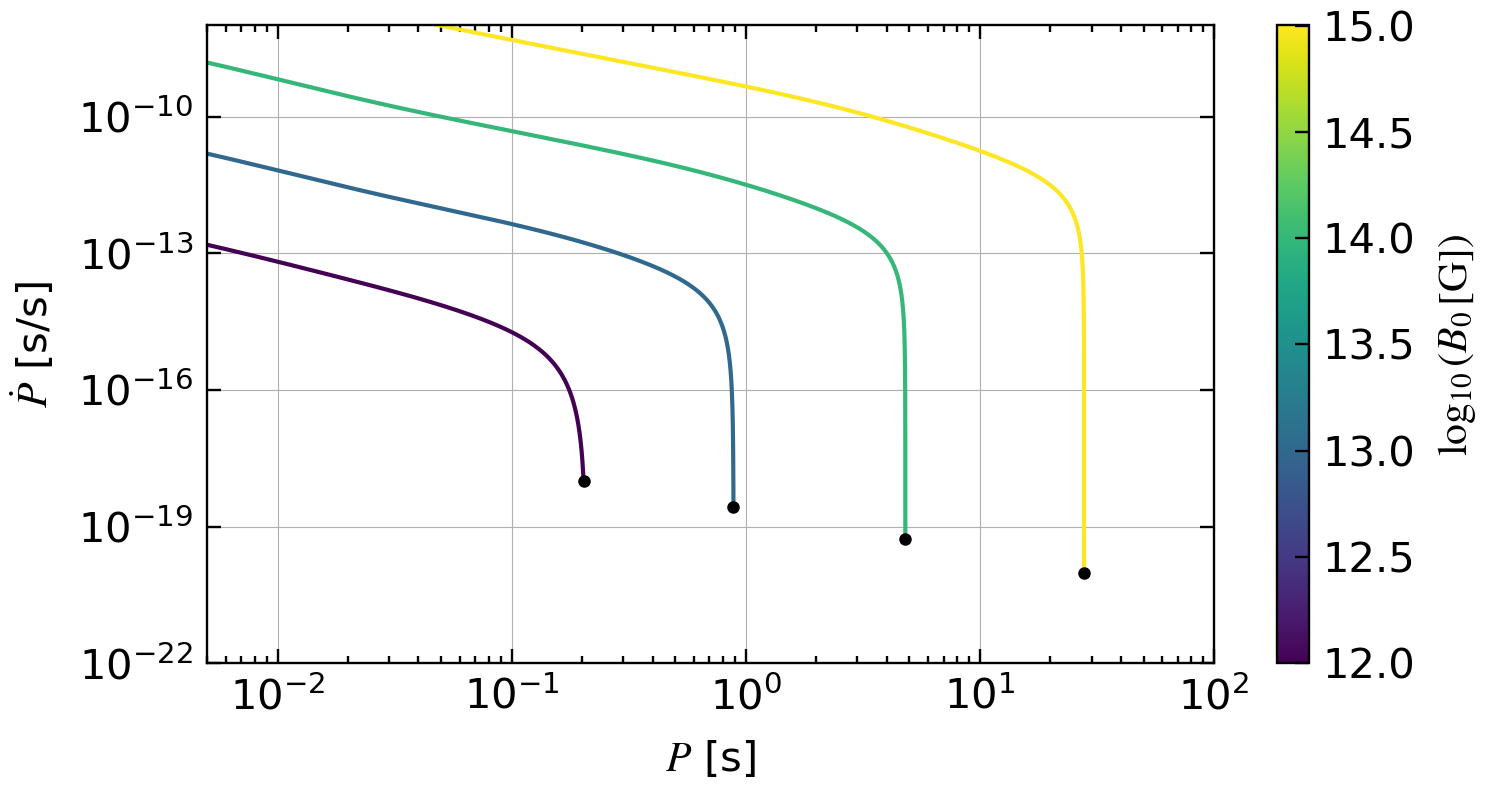

In [8]:
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(log_B0)):
    ax.loglog(P[i], P_dot[i], "-", lw=3, color=cmap(norm(log_B0[i])))
    ax.loglog(P_initial[i], P_dot_initial[i], "o", color="gray", ms=8)
    ax.loglog(P_final[i], P_dot_final[i], "o", color="black", ms=8)

ax.set_xlim(5e-3, 1e2)
ax.set_ylim(1e-22, 1e-8)
plt.xlabel(r"$P$ [s]")
plt.ylabel(r"$\dot{P}$ [s/s]")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()

Check the magnetic field evolution.

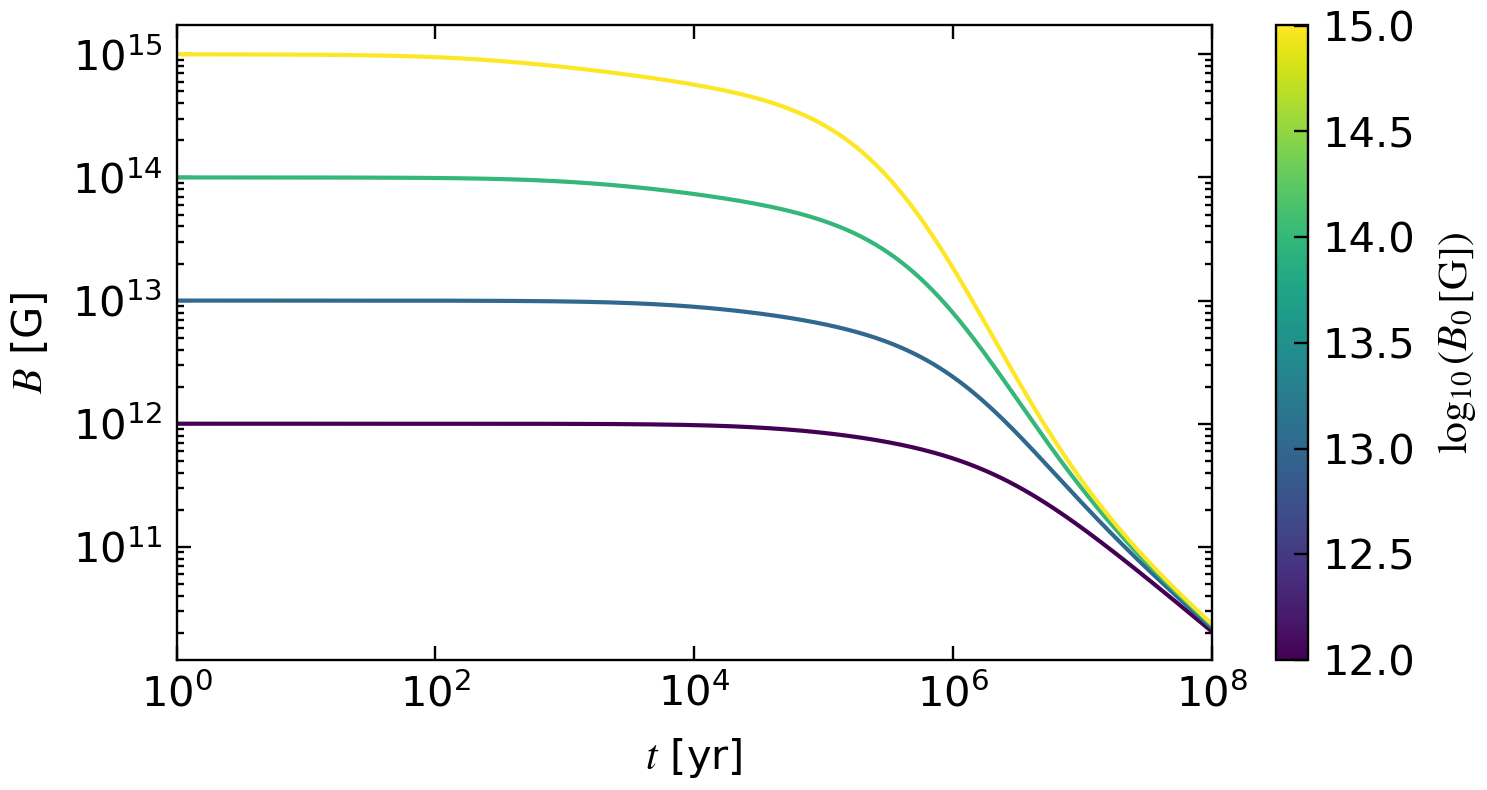

In [9]:
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(log_B0)):
    ax.loglog(t[i], B[i], "-", color=cmap(norm(log_B0[i])), lw=3)

ax.set_xlim(1, 1e8)

plt.xlabel(r"$t$ [yr]")
plt.ylabel(r"$B$ [G]")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

Check the inclination angle evolution.

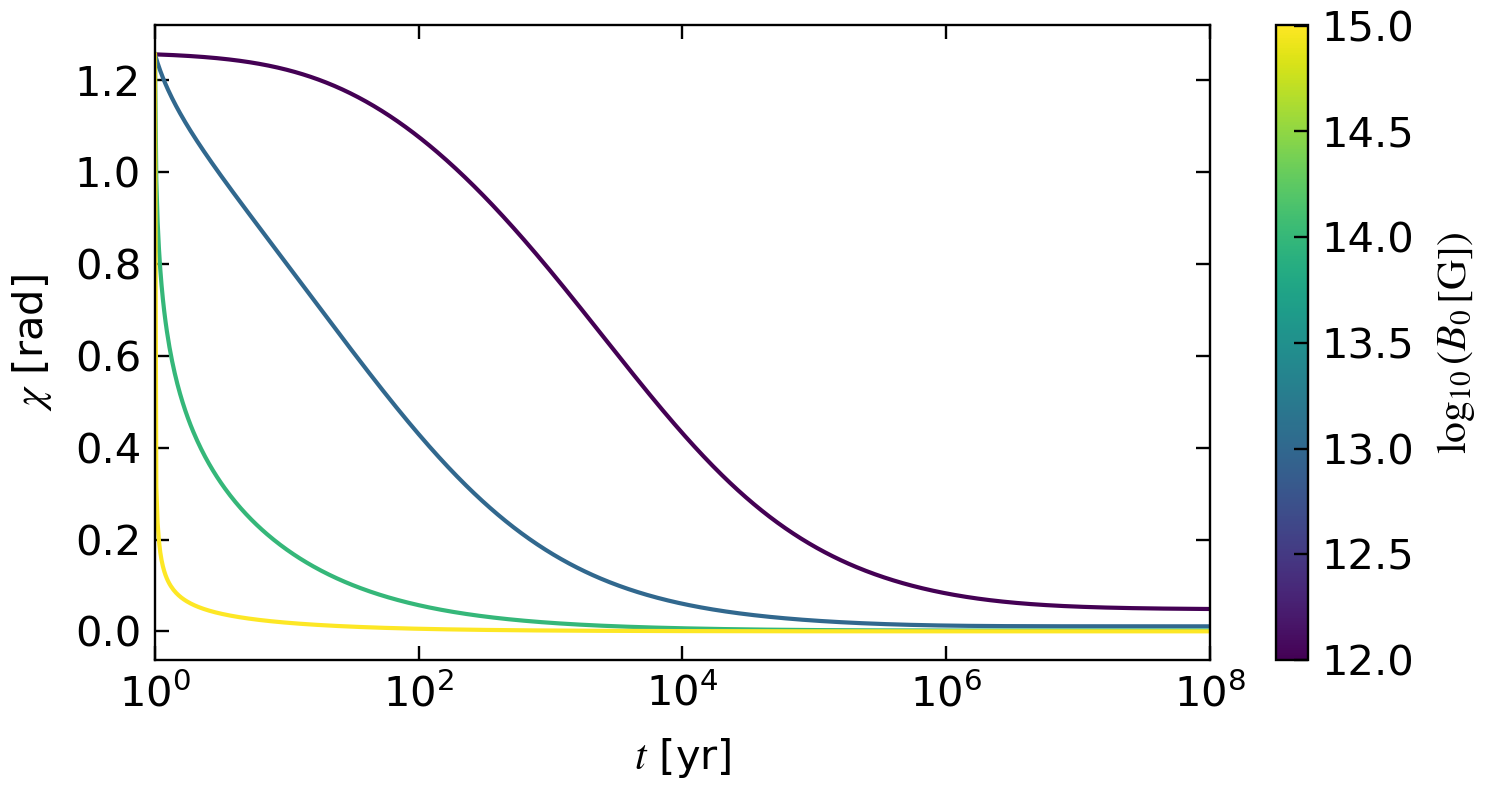

In [10]:
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(log_B0)):
    ax.plot(t[i], chi[i], "-", color=cmap(norm(log_B0[i])), lw=3)

ax.set_xlim(1, 1e8)
ax.set_xscale("log")
plt.xlabel(r"$t$ [yr]")
plt.ylabel(r"$\chi$ [rad]")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

Check the spin-period evolution. 

NOTE: the evolution before 10 yrs for high magnetic fields has some numerical issues since we set the starting time of evolution at 1 yr in the method `magneto_rotational_evolution_fit` in the module `popsyn/magneto_rotational_physics/magneto_rotational_evolution_fit`. To solve that you have to set the start time to be earlier like 0.01 yr. However this doesn't affect the long-term evolution and the final results. 

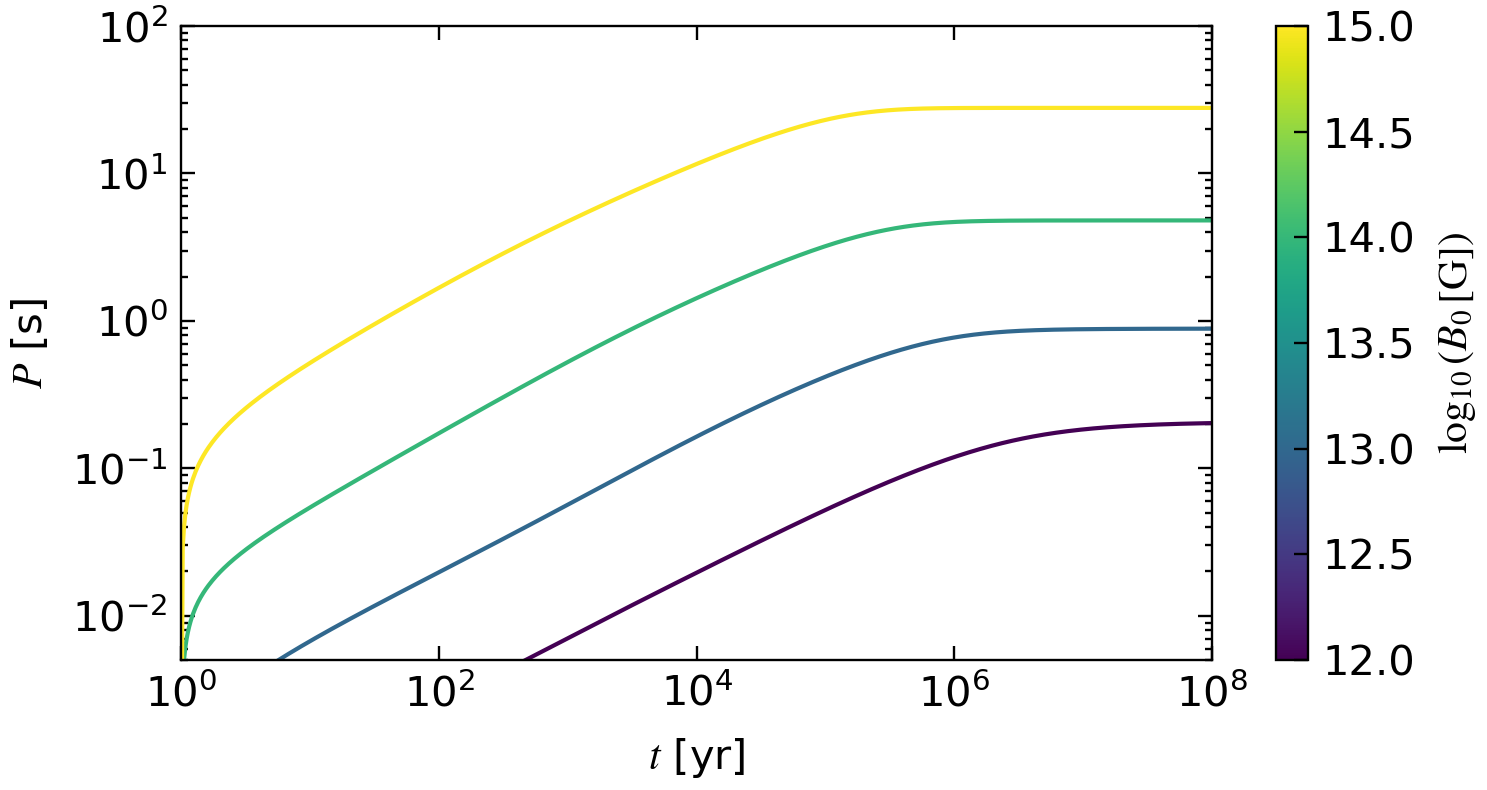

In [11]:
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(log_B0)):
    ax.plot(t[i], P[i], "-", color=cmap(norm(log_B0[i])), lw=3)

ax.set_xlim(1.0, 1e8)
ax.set_ylim(5e-3, 1e2)
ax.set_xscale("log")
ax.set_yscale("log")

plt.xlabel(r"$t$ [yr]")
plt.ylabel(r"$P$ [s]")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

Compare the characteristic age with the real age.

NOTE: In the assumption of constant magnetic field and dipolar spin down, the age of a pulsar born with an initial spin period $P_0$ is: 
\begin{equation}
    t_{\rm age} = \frac{P}{2\dot{P}}\left[1-\left(\frac{P_0}{P} \right)^2\right]
\end{equation}

The characteristic age, $\tau_{\rm c} = P/(2P_0)$, always defines an upper limit for the real age and it is evaluated in the assumptions of constant field and $P \gg P_0$ where $P_0$ is the initial spin period. 

In the first part of the evolution the characteristic age overestimates the real age due to the fact that the approximation $P \gg P_0$ does not apply. The initial spin period starts evolving after a characteristic time-scale that depends on the initial spin period and magnetic field. This time-scale is defined as
$t_{\rm em} = P_0^2 / (8 \pi 2 \beta B_0^2)$,
where $\beta \sim R_{\rm NS}^6 / (4 c^3 I_{\rm NS}) \sim 1.5 \times 10^{-41}$ s G$^{-2}$. For times $t \ll t_{\rm em}$ the spin period $P$ is still close to the initial one $P_0$, therefore the characteristic age fails to give a good estimate of the real age.
For later times the characteristic age overestimates the real age due to the effect of magnetic field decay. 

In [12]:
tau_c = np.array(P) / (2*np.array(P_dot)) / const.YR_TO_S

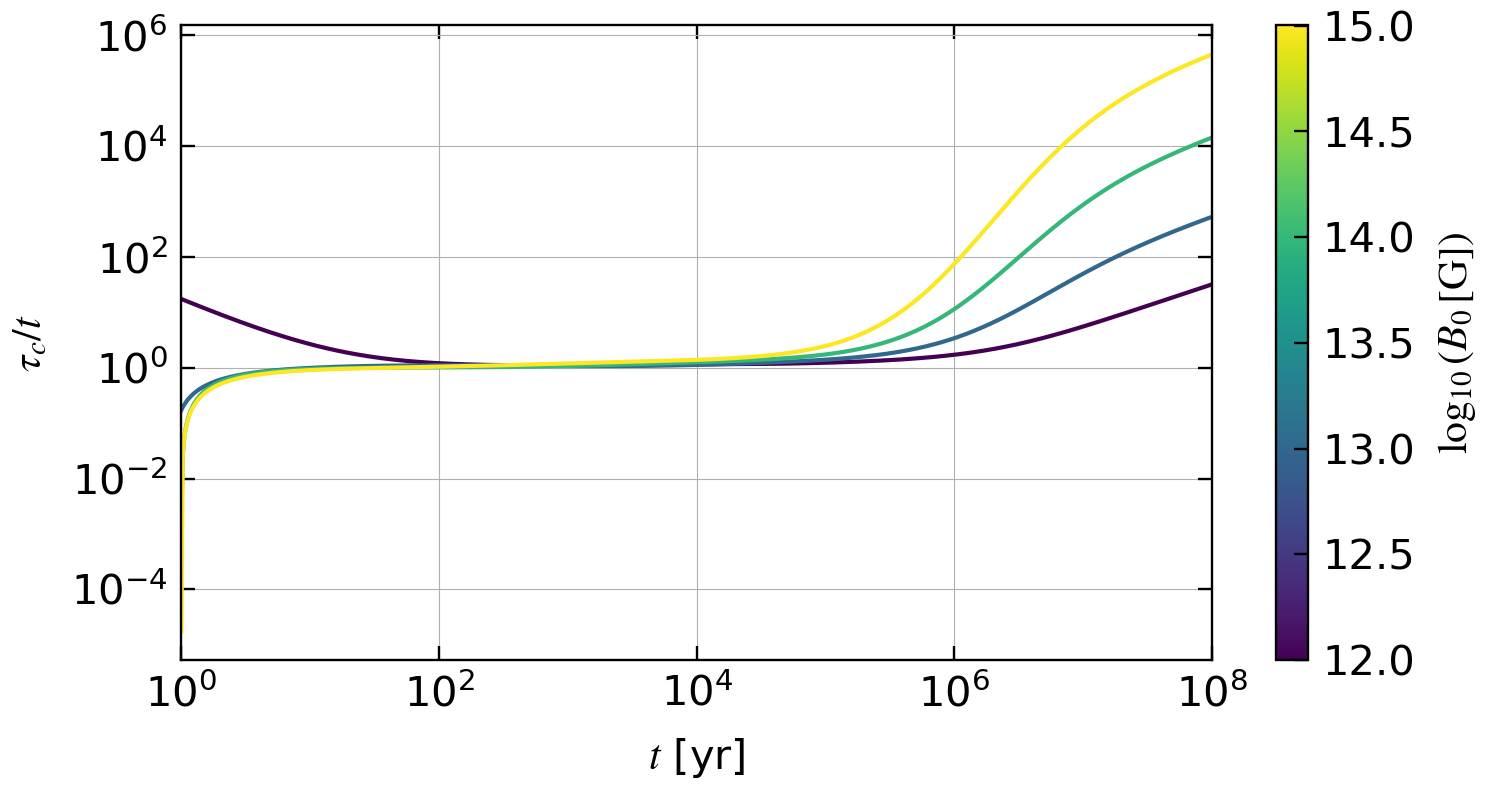

In [13]:
fig, ax = plt.subplots(figsize=(15, 8))

for i in range(len(log_B0)):
    ax.plot(t[i], tau_c[i] / t[i], "-", color=cmap(norm(log_B0[i])), lw=3)

ax.set_xlim(1.0, 1e8)
#ax.set_ylim(5e-3, 1e2)
ax.set_xscale("log")
ax.set_yscale("log")

plt.xlabel(r"$t$ [yr]")
plt.ylabel(r"$\tau_c/t$")

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()